In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import os, pickle, torch
import vima
torch.set_default_device('mps') # edit as appropriate to hardware
vima.set_seed(0) # for reproducibility
os.makedirs(f'./_results', exist_ok=True)

%run ../common.py

# Train

## RA

In [3]:
# read in samples
def fname_parser(fname):
    fname = os.path.splitext(os.path.basename(fname))[0]
    return {
        'donor': fname.split('_')[0].replace('Repeat',''),
        'sid': fname
    }
repname = 'pca_k=5_harmony'
samples = vima.read_samples(f'../../RA/BHAM-data/10u/{repname}/*.nc', fname_parser)

# read in and reformat sample metadata
fullmeta = pd.read_csv('../../RA/BHAM-data/ihc-metadata.csv').set_index('subject_id')[['CTAP']]
fullmeta.index = fullmeta.index.str.replace('V0', '') # reformat sample names
fullmeta['fstar'] = (fullmeta.CTAP == 'F') | (fullmeta.CTAP == 'T + F') | (fullmeta.CTAP == 'E + F + M') # define our phenotype

  0%|                                                                        | 0/27 [00:00<?, ?it/s]

100%|███████████████████████████████████████████████████████████████| 27/27 [00:05<00:00,  4.80it/s]


In [3]:
# choose which patches to train on
P = vima.PatchCollection(samples)
print(len(P), 'patches')

# choose which patches to do case/ctrl analysis on
Pdense = vima.PatchCollection(samples, max_frac_empty=0.2, sid_nums=P.sid_nums)
print(len(Pdense), 'dense patches')

# change samplemeta so that each row is a sample rather than a donor
inourdata = P.meta[['sid','donor']].drop_duplicates()
samplemeta = pd.merge(inourdata, fullmeta, left_on='donor', right_index=True, how='left').set_index('sid', drop=True)

100%|███████████████████████████████████████████████████████████████| 27/27 [00:07<00:00,  3.52it/s]


in pytorch mode
means: [-0.05321763 -0.03295922 -0.00334221 -0.02601908  0.00115162]
stds: [0.7902036  0.7818226  0.755552   0.52920806 0.39248583]
data augmentation is off
39302 patches


100%|███████████████████████████████████████████████████████████████| 27/27 [00:04<00:00,  6.23it/s]


in pytorch mode
means: [-0.02139742  0.01625216  0.15783702  0.01341044  0.03330246]
stds: [1.0030323  1.0223271  0.9711682  0.68478453 0.5379764 ]
data augmentation is off
10345 dense patches


end of epoch 20: avg val loss = 0.5673665031790733
time elapsed this epoch: 329.96 sec
total time elapsed: 6572.86 sec


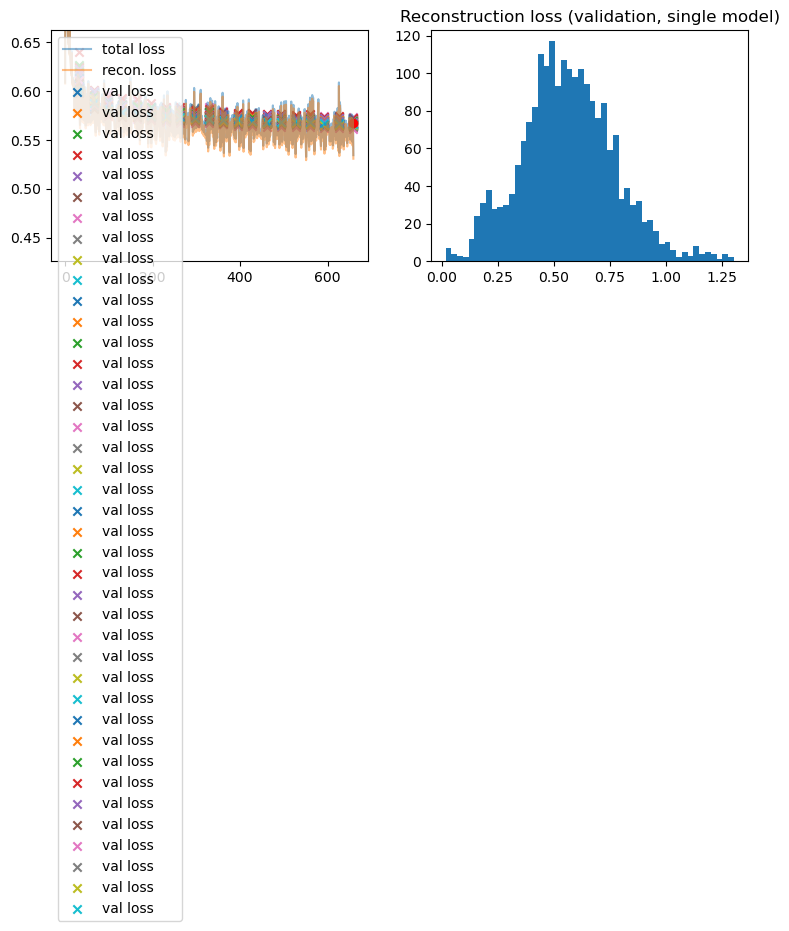

best validation losses so far across full model ensemble: [0.56591374, 0.56822324, 0.56743145, 0.56820196, 0.56921685, 0.57084864, 0.57302326, 0.57238334, 0.5658204, 0.5641943, 0.56454825, 0.5657406, 0.569394, 0.57251436, 0.5650552, 0.56349707, 0.5613916, 0.56884134, 0.5684694, 0.56514794, 0.5698554, 0.56997246, 0.56636256, 0.57096356, 0.57068247, 0.56399536, 0.5676739, 0.56509703, 0.5661226, 0.5663418, 0.56600887, 0.56946844, 0.56915283, 0.567718, 0.5684111, 0.56661385, 0.5653477, 0.5639662, 0.5647356, 0.56631345]
best epochs so far across full model ensemble: [20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20]


In [ ]:
models = vima.models.cVAE(P.nmarkers, P.nsamples, nreps=40)

log = vima.train(models, P, n_epochs=10)
log2 = vima.train(models, Pdense, n_epochs=20)
torch.save(models.state_dict(), f'_results/models-ra.pt')

import pickle
with open('_results/log-ra', 'wb') as f:
    pickle.dump(log, f)
with open('_results/log2-ra', 'wb') as f:
    pickle.dump(log2, f)

In [ ]:
# load model
models = vima.models.cVAE(P.nmarkers, P.nsamples, nreps=40)
models.load_state_dict(torch.load(f'_results/models-ra.pt'))

# apply models and build nearest-neighbor graphs
ds = vima.latentreps(models, Pdense)
pickle.dump(ds, open(f'_results/fingerprints-ra.pkl', 'wb'))

applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 11/11 [00:20<00:00,  1.85s/it]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 40/40 [01:04<00:00,  1.61s/it]


In [ ]:
import gc
ds = pickle.load(open(f'_results/fingerprints-ra.pkl', 'rb'))
seeds = np.random.choice(10000, size=1000, replace=False)
results = pd.DataFrame(columns=['nvaes', 'niter', 'p'])
mncoefs = []
sigmncoefs = []

si = 0
for nvaes in [1, 5, 10, 20]:
    for niter in range(10):
        np.random.seed(seeds[si]); si += 1
        ind = np.random.choice(len(ds), size=nvaes, replace=True)
        ds_ = [ds[i] for i in ind]
        print(ind)
        p, D = vima.association(ds_, samplemeta.fstar, 'sid', donorids=samplemeta.donor, make_umap=False, Nnull=10000)
        mncoefs.append(D.obs.mncoef)
        print(f'found {(D.obs.mncoef_fdr <= 0.1).sum()} microniches at FDR 10%')
        sigmncoefs.append(D.obs.mncoef.where(D.obs.mncoef_fdr <= 0.1, 0))
        
        # Add new row to results DataFrame
        results = pd.concat([
            results,
            pd.DataFrame({'nvaes': nvaes, 'niter': niter, 'p': p}, index=[0])
        ], ignore_index=True)
        del D; del ds_; gc.collect()

results.to_csv('_results/association-ra.csv', index=False)
sigmncoefs = np.array(sigmncoefs)
np.save('_results/sigmncoefs-ra.npy', sigmncoefs)
mncoefs = np.array(mncoefs)
np.save('_results/mncoefs-ra.npy', mncoefs)

[28]
computing MAT
performing association test
P = 0.00019998000199980003


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


found 3623 microniches at FDR 10%
[10]
computing MAT


/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_40457/1073771165.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([


performing association test
P = 0.0006999300069993001


...

found 5293 microniches at FDR 10%
[31 28  0  8  7 29  7 10 25  6 35  6 34 20 18 26 38 30 20 34]
computing MAT
performing association test
P = 0.00019998000199980003


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


found 5237 microniches at FDR 10%
[32 30 22 16 38 38 30  8  0 12 21 17 37  9 20  7 21 19 11 18]
computing MAT
performing association test
P = 0.00019998000199980003


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


found 5273 microniches at FDR 10%


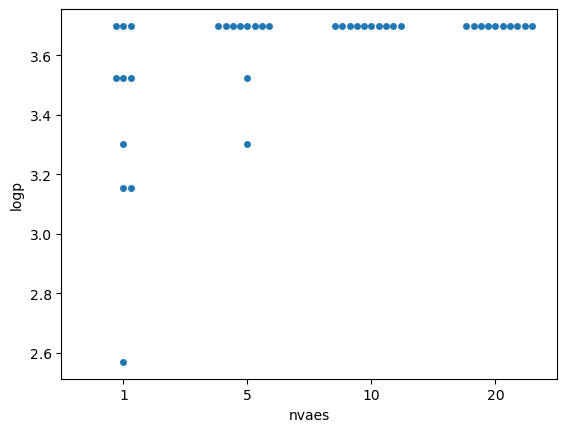

<Axes: xlabel='nvaes', ylabel='nsig'>

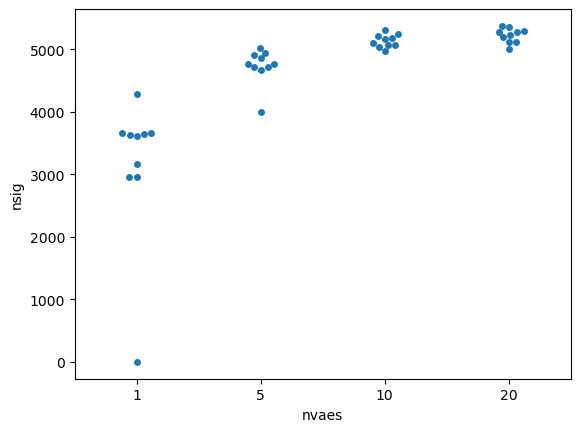

In [5]:
import seaborn as sns
results['nsig'] = [ (sigmncoef != 0).sum() for sigmncoef in sigmncoefs ]
results['logp'] = -np.log10(results['p'])
sns.swarmplot(data=results, x='nvaes', y='logp')
plt.show()
sns.swarmplot(data=results, x='nvaes', y='nsig')

## UC

In [2]:
# read in samples
def fname_parser(fname): 
    fname = fname.split("/")[-1].split(".nc")[0]
    if fname[-1].islower():
        donor = fname[:-1]
    else: 
        donor = fname
    return {'sid': fname, 'donor': donor}

repname = 'pca_k=10_harmony'
samples = vima.read_samples(f'../../UC/UC-data/10u/{repname}/*.nc', fname_parser)

# read in sample metadata
samplemeta = pd.read_csv('../../UC/UC-data/2024_10_16_UC_Patient_Metadata.csv').rename(columns={'NEW Label':'sid', 'Patient.ID':'donor'}).set_index('sid', drop=True)
samplemeta.donor = samplemeta.donor.astype('str')

# add in phenotypes
samplemeta['UC'] = (samplemeta.Status == 'UC').astype('float')
samplemeta.loc[(samplemeta.TNFnow == 'y') | (samplemeta.TNFprior == 'y'), 'UC'] = np.nan
samplemeta['TNF'] = (samplemeta.TNFprior == 'y').astype('float')
samplemeta.loc[samplemeta.UC == 0, 'TNF'] = np.nan

100%|███████████████████████████████████████████████████████████████| 42/42 [00:01<00:00, 35.78it/s]


In [3]:
# choose which patches to train on
P = vima.PatchCollection(samples)
print(len(P), 'patches')

# choose which patches to do case/ctrl analysis on
Pdense = vima.PatchCollection(samples, max_frac_empty=0.5, sid_nums=P.sid_nums)
print(len(Pdense), 'dense patches')

100%|███████████████████████████████████████████████████████████████| 42/42 [00:03<00:00, 12.63it/s]


in pytorch mode
means: [ 0.05447359  0.00932357 -0.01125651 -0.08395857 -0.0760752  -0.00231467
  0.02149703 -0.02244353  0.03177896  0.03401043]
stds: [2.762697   1.6159511  1.5329615  0.98749584 0.7044896  0.695698
 0.84755    0.71394193 0.84401417 0.70302254]
data augmentation is off
25869 patches


100%|███████████████████████████████████████████████████████████████| 42/42 [00:02<00:00, 15.96it/s]


in pytorch mode
means: [ 0.02617896 -0.01365452 -0.02929876 -0.0981875  -0.08734448 -0.00903606
  0.02480437 -0.02955827  0.02544119  0.02641205]
stds: [2.8995552  1.7140516  1.6182748  1.0435452  0.7490146  0.73932135
 0.8920543  0.7566857  0.8822612  0.74306035]
data augmentation is off
21359 dense patches


end of epoch 20: avg val loss = 0.6401409640908241
time elapsed this epoch: 604.49 sec
total time elapsed: 15787.53 sec


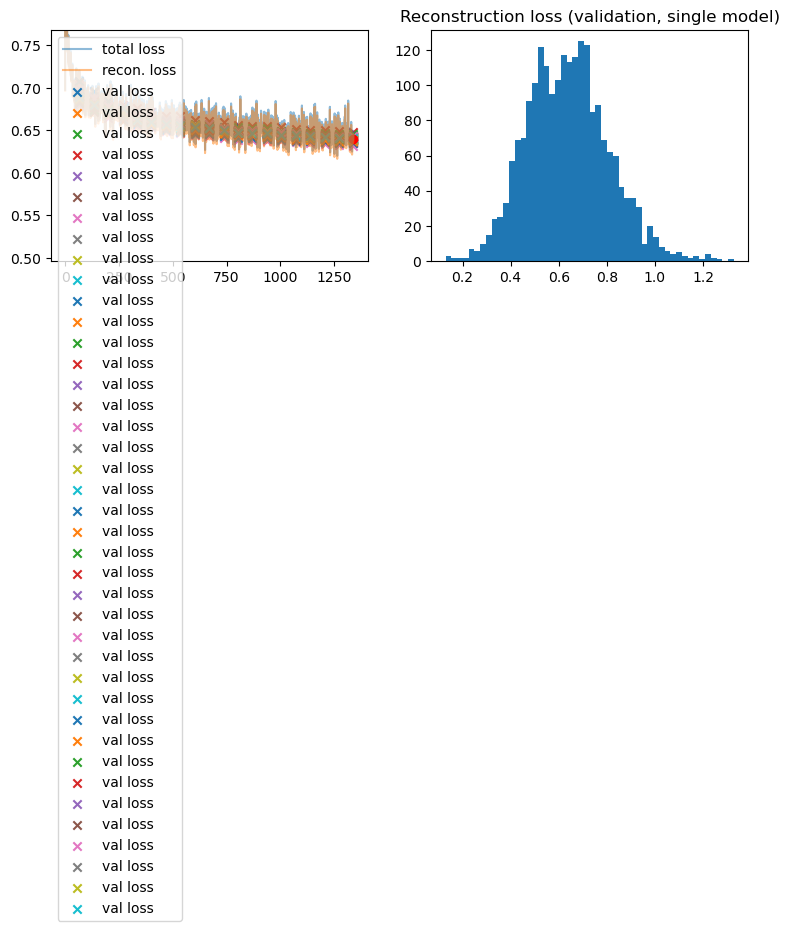

best validation losses so far across full model ensemble: [0.6439814, 0.6350078, 0.6426936, 0.64829135, 0.63724655, 0.6384202, 0.64379233, 0.6413803, 0.64321077, 0.6380584, 0.6435077, 0.6380605, 0.6454889, 0.6384508, 0.6356372, 0.6423366, 0.6320744, 0.6411969, 0.6424269, 0.6394303, 0.6352175, 0.63901174, 0.6385705, 0.6419879, 0.63840413, 0.6366469, 0.6436141, 0.63699496, 0.638847, 0.63958067, 0.6401516, 0.63737535, 0.6401038, 0.63932127, 0.64235765, 0.642647, 0.6422793, 0.639665, 0.6400373, 0.64135456]
best epochs so far across full model ensemble: [20, 20, 20, 20, 20, 20, 20, 20, 19, 20, 20, 20, 19, 20, 20, 20, 20, 20, 20, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 19, 20, 19, 20, 20, 20]


In [ ]:
models = vima.models.cVAE(P.nmarkers, P.nsamples, nreps=40)

log = vima.train(models, P, n_epochs=10)
log2 = vima.train(models, Pdense, n_epochs=20)
torch.save(models.state_dict(), f'_results/models-uc.pt')

import pickle
with open('_results/log-uc', 'wb') as f:
    pickle.dump(log, f)
with open('_results/log2-uc', 'wb') as f:
    pickle.dump(log2, f)

In [6]:
# load model
models = vima.models.cVAE(P.nmarkers, P.nsamples, nreps=40)
models.load_state_dict(torch.load(f'_results/models-uc.pt'))

# apply models and build nearest-neighbor graphs
ds = vima.latentreps(models, Pdense)
pickle.dump(ds, open(f'_results/fingerprints-uc.pkl', 'wb'))

applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 22/22 [00:41<00:00,  1.89s/it]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 40/40 [01:28<00:00,  2.20s/it]


In [7]:
import gc
ds = pickle.load(open(f'_results/fingerprints-uc.pkl', 'rb'))
seeds = np.random.choice(10000, size=1000, replace=False)
results = pd.DataFrame(columns=['nvaes', 'niter', 'p'])
mncoefs = []
sigmncoefs = []

si = 0
for nvaes in [1, 5, 10, 20]:
    for niter in range(10):
        np.random.seed(seeds[si]); si += 1
        ind = np.random.choice(len(ds), size=nvaes, replace=True)
        ds_ = [ds[i] for i in ind]
        print(ind)
        p, D = vima.association(ds_, samplemeta.UC, 'sid', donorids=samplemeta.donor, make_umap=False, Nnull=10000)
        mncoefs.append(D.obs.mncoef)
        print(f'found {(D.obs.mncoef_fdr <= 0.1).sum()} microniches at FDR 10%')
        sigmncoefs.append(D.obs.mncoef.where(D.obs.mncoef_fdr <= 0.1, 0))
        
        # Add new row to results DataFrame
        results = pd.concat([
            results,
            pd.DataFrame({'nvaes': nvaes, 'niter': niter, 'p': p}, index=[0])
        ], ignore_index=True)
        del D; del ds_; gc.collect()

results.to_csv('_results/association-uc.csv', index=False)
sigmncoefs = np.array(sigmncoefs)
np.save('_results/sigmncoefs-uc.npy', sigmncoefs)
mncoefs = np.array(mncoefs)
np.save('_results/mncoefs-uc.npy', mncoefs)

[4]
computing MAT
performing association test
P = 0.0040995900409959


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


found 3333 microniches at FDR 10%


/var/folders/w_/x2_v44_93nq_b3svp199t1rw0000gn/T/ipykernel_42126/48962746.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat([


[32]
computing MAT
performing association test
P = 0.0005999400059994001


...

found 11923 microniches at FDR 10%
[37  8 21 26 37  4 29 28 16  2  7 27 30 13 36  3  2  5 35 29]
computing MAT
performing association test
P = 0.0012998700129987


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


found 11027 microniches at FDR 10%
[ 7  8 38 28 11 34 30 29 38 35 38 13 29  4 13  8  0 35 14 36]
computing MAT
performing association test
P = 0.0018998100189981002


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


found 10336 microniches at FDR 10%


## ALZ

In [ ]:
# read in samples
repname = 'pca_k=10_harmony'
samples = vima.read_samples(f'../../ALZ/alz-data/10u/{repname}/*.nc', vima.default_parser)

# read in sample metadata
samplemeta = pd.read_csv('../../ALZ/alz-data/sea-ad_cohort_donor_metadata_encoded_20240924.tsv',
                         sep='\t').set_index('Donor ID', drop=True)
samplemeta['case'] = samplemeta['Consensus Clinical Dx (choice=Control)'] != 'Checked'

100%|███████████████████████████████████████████████████████████████| 75/75 [00:09<00:00,  7.63it/s]


In [ ]:
# choose which patches to train on
P = vima.PatchCollection(samples)
print(len(P), 'patches')

# choose which patches to do case/ctrl analysis on
Pdense = vima.PatchCollection(samples, max_frac_empty=0.5, sid_nums=P.sid_nums)
print(len(Pdense), 'dense patches')

# change samplemeta so that each row is a sample rather than a donor
inourdata = P.meta[['sid','donor']].drop_duplicates()
samplemeta = pd.merge(inourdata, samplemeta, left_on='donor', right_index=True, how='left').set_index('sid', drop=True)

100%|███████████████████████████████████████████████████████████████| 75/75 [00:21<00:00,  3.45it/s]


in pytorch mode
means: [ 0.02986116  0.01653604  0.00962785  0.01290399  0.06818598 -0.0326423
 -0.00355617 -0.03974951  0.01444293 -0.0089395 ]
stds: [1.4061769  1.2024021  1.0249848  0.95184785 0.8701892  0.8797922
 0.92340004 0.79765475 0.77515084 0.75295   ]
data augmentation is off
172202 patches


100%|███████████████████████████████████████████████████████████████| 75/75 [00:10<00:00,  6.99it/s]


in pytorch mode
means: [ 0.26470545  0.01536486 -0.02125615  0.08961389  0.08553316 -0.03282372
  0.03094853 -0.059366    0.00159962 -0.00730543]
stds: [1.4914511  1.3240349  1.1581167  1.0942996  0.99748695 1.0070354
 1.0190866  0.92461044 0.88224757 0.8898988 ]
data augmentation is off
70898 dense patches


end of epoch 20: avg val loss = 0.9329410865902901
time elapsed this epoch: 1813.31 sec
total time elapsed: 37770.63 sec


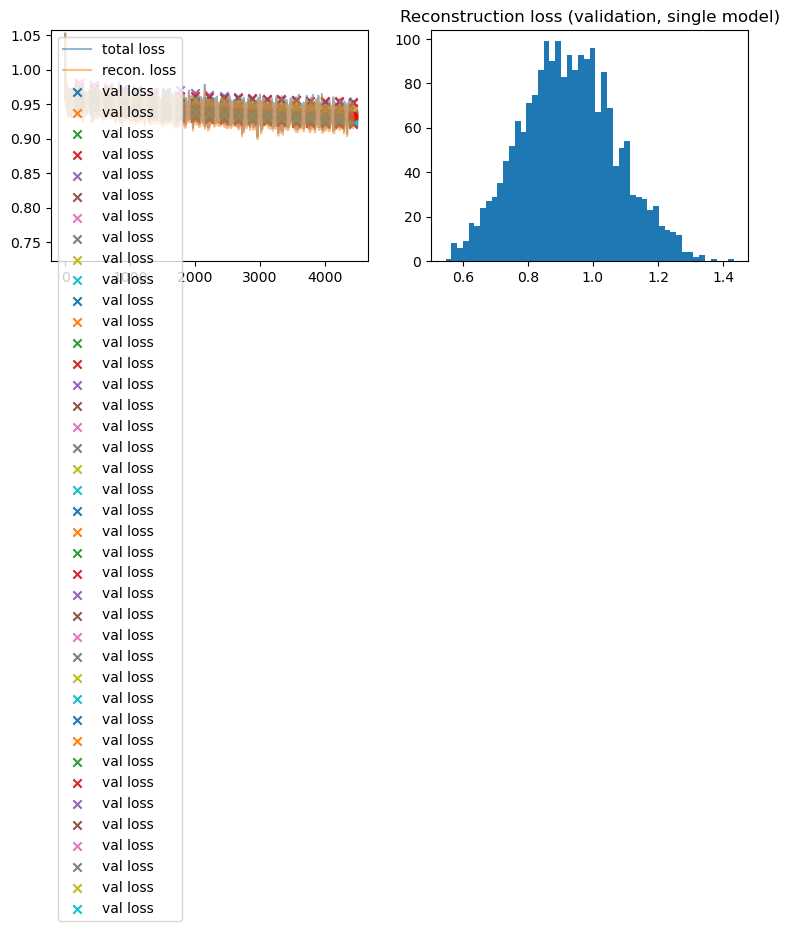

best validation losses so far across full model ensemble: [0.929357, 0.9428517, 0.93566614, 0.93227154, 0.92659223, 0.92791045, 0.92690074, 0.93676245, 0.92223346, 0.92410684, 0.93023986, 0.9357698, 0.93270254, 0.9212602, 0.92566365, 0.93376356, 0.9345598, 0.93338645, 0.93028975, 0.9338367, 0.9250805, 0.9453053, 0.929772, 0.9326577, 0.95170176, 0.92455983, 0.9411378, 0.9338319, 0.9342662, 0.92657655, 0.93198055, 0.9327119, 0.934617, 0.95409065, 0.9295197, 0.9351717, 0.93459994, 0.9341468, 0.9401313, 0.9296515]
best epochs so far across full model ensemble: [20, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20]


In [ ]:
models = vima.models.cVAE(P.nmarkers, P.nsamples, nreps=40)

log = vima.train(models, P, n_epochs=10)
log2 = vima.train(models, Pdense, n_epochs=20)
torch.save(models.state_dict(), f'_results/models-alz.pt')

import pickle
with open('_results/log-alz', 'wb') as f:
    pickle.dump(log, f)
with open('_results/log2-alz', 'wb') as f:
    pickle.dump(log2, f)

# Make latent reps

## RA